ref1:
https://github.com/abhisheksuran/Reinforcement_Learning/blob/master/Td3.py   
ref2: https://github.com/sfujim/TD3/blob/master/TD3.py


gym:https://www.gymlibrary.dev/environments/box2d/lunar_lander/   


In [1]:
from google.colab import drive
drive.mount("./gdrive")

Mounted at ./gdrive


In [2]:
path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')
from variable_print import p,ps,pst

In [3]:
import gym
import tensorflow as tf
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import random
from collections import deque

/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/util.py:55: DeprecationWarning: jax.xla_computation is deprecated. Please use the AOT APIs; see https://jax.readthedocs.io/en/latest/aot.html. For example, replace xla_computation(f)(*xs) with jit(f).lower(*xs).compiler_ir('hlo'). See CHANGELOG.md for 0.4.30 for more examples.
  from jax import xla_computation as _xla_computation


In [4]:
%%time
%%capture
!pip install swig
!pip install gym[box2d]

CPU times: user 343 ms, sys: 63.1 ms, total: 406 ms
Wall time: 1min


# LunarLander_Continuous Environment

In [ ]:
problem = "LunarLanderContinuous-v2"
env = gym.make(problem,new_step_api=True)

num_states = env.observation_space.shape[0]      # 8
ps(env.observation_space,'Shape of State Space') #(8,)
p(env.observation_space,'env.observation_space')
print(f'state_low::{env.observation_space.low}')
print(f'state_high::{env.observation_space.high}\n')

num_actions = env.action_space.shape[0] # 2
ps(env.action_space,'Shape of Action Space') #(2,)
p(env.action_space,'env.action_space')
print(f'action_low::{env.action_space.low}')
print(f'action_high::{env.action_space.high}\n')

state = env.reset()
p(state,'state') #(8,)

# Replay Buffer

In [6]:
class RBuffer():
  def __init__(self, buffer_capacity, batch_size, num_states, num_actions):
    self.batch_size = batch_size
    self.buffer_capacity = buffer_capacity
    self.buffer_counter = 0  # 저장 횟수
    self.states = np.zeros((self.buffer_capacity, num_states))
    self.actions = np.zeros((self.buffer_capacity, num_actions))
    self.rewards = np.zeros((self.buffer_capacity, 1))
    self.next_states = np.zeros((self.buffer_capacity, num_states))
    self.not_dones = np.zeros((self.buffer_capacity, 1))

  def record(self, state, action, reward, next_state, done):
    index = self.buffer_counter % self.buffer_capacity
    self.states[index] = state
    self.actions[index] = action
    self.rewards[index] = reward
    self.next_states[index] = next_state
    self.not_dones[index] = 1 - done
    self.buffer_counter += 1

  def get_batch(self):
    record_range = min(self.buffer_counter, self.buffer_capacity)
    batch = np.random.choice(record_range, self.batch_size, replace=False)
    state_batch = tf.convert_to_tensor(self.states[batch], dtype= tf.float32)
    action_batch = tf.convert_to_tensor(self.actions[batch], dtype= tf.float32)
    reward_batch = tf.convert_to_tensor(self.rewards[batch], dtype= tf.float32)
    next_state_batch = tf.convert_to_tensor(self.next_states[batch], dtype= tf.float32)
    not_done_batch = tf.convert_to_tensor(self.not_dones[batch], dtype= tf.float32)
    return state_batch, action_batch, reward_batch, next_state_batch, not_done_batch

# TD3

## Actor-Network, Critic-Network(shared model)    

In [7]:
env.observation_space.shape

(8,)

In [8]:
def Critic(nodes=256):
    in_state = keras.Input(shape=env.observation_space.shape)#(8,)
    in_action = keras.Input(shape=env.action_space.shape)    #(2,)
    in_data = layers.concatenate([in_state, in_action],axis=1)
    x = layers.Dense(nodes, activation='relu')(in_data)
    x1 = layers.Dense(nodes, activation='relu')(x)
    x1 = layers.Dense(nodes, activation='relu')(x1)
    x1 =  layers.Dense(1, activation='linear',name='q1')(x1)

    x2 = layers.Dense(nodes, activation='relu')(x)
    x2 = layers.Dense(nodes, activation='relu')(x2)
    x2 =  layers.Dense(1, activation='linear',name='q2')(x2)
    q1_q2 = keras.Model([in_state,in_action],[x1,x2], name='Q1_Q2')
    return q1_q2

def Actor(nodes=256):
    in_state = keras.Input(shape=env.observation_space.shape)#(8,)
    x = layers.Dense(nodes, activation='relu')(in_state)
    x = layers.Dense(nodes, activation='relu')(x)
    x = layers.Dense(num_actions, activation='tanh')(x)
    return keras.Model(in_state,x,name="Actor")

Model: "Q1_Q2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 8)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 2)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 10)             │              0 │ input_layer[0][0],     │
│                           │                        │                │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 256)            │          2,816 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 256)            │         65,792 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 256)            │         65,792 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ q1 (Dense)                │ (None, 1)              │            257 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ q2 (Dense)                │ (None, 1)              │            257 │ dense_2[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 134,914 (527.01 KB)

 Trainable params: 134,914 (527.01 KB)

 Non-trainable params: 0 (0.00 B)

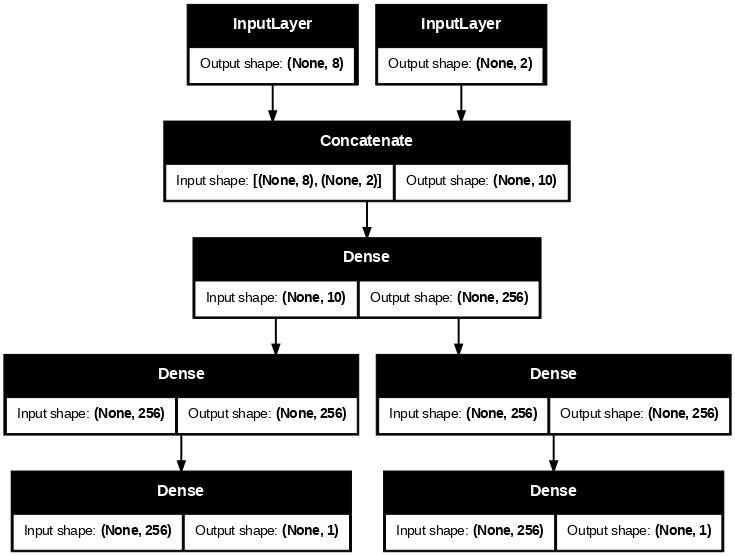

In [9]:
q1_q2 = Critic()
q1_q2.summary()
keras.utils.plot_model(q1_q2,'q1_q2.png',show_shapes=True,dpi=70)

Model: "Actor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,610 (268.01 KB)

 Trainable params: 68,610 (268.01 KB)

 Non-trainable params: 0 (0.00 B)

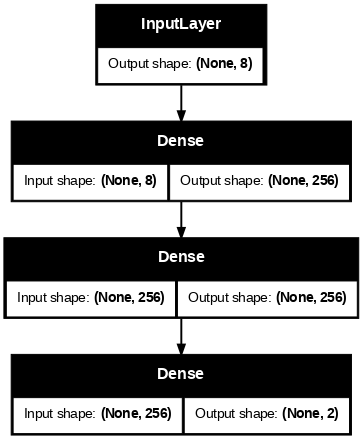

In [10]:
actor = Actor()
actor.summary()
keras.utils.plot_model(actor,'actor.png',show_shapes=True,dpi=70)

## TD3 Agent

In [12]:
class Agent():
  def __init__(self, env, buffer_capacity=100000, batch_size=64):
    # NNetworks instantiation
    self.actor_main = Actor()
    self.actor_target = Actor()
    self.q1_q2_main = Critic()
    self.q1_q2_target = Critic()
    # Parameter copy
    self.update_target(self.actor_target.weights, self.actor_main.weights, tau=1.0)
    self.update_target(self.q1_q2_target.weights, self.q1_q2_main.weights, tau=1.0)

    # Optimizer definition
    self.a_lr = 0.001 #0.001
    self.c_lr = 0.001 #0.002
    self.a_opt = tf.keras.optimizers.Adam(self.a_lr)
    self.c_opt = tf.keras.optimizers.Adam(self.c_lr)

    # Action space
    self.n_actions = len(env.action_space.high) # 2
    self.min_action = env.action_space.low[0]   # -1.0
    self.max_action = env.action_space.high[0]  # 1.0    self.train_step = 0 # No. of Iterations

    # Hyper Param.
    self.batch_size = batch_size
    self.actor_update_steps = 2
    self.warmup = 2000
    self.gamma = 0.99
    self.tau = 0.005 #0.02 #0.005 #0.05
    self.expl_noise = 0.1
    self.warmup_noise = 1.0

    self.num_states = env.observation_space.shape[0] # 8
    self.num_actions = env.action_space.shape[0]     # 2

    self.train_step = 0
    self.loss_q = 0
    self.loss_a = 0
    self.losses = []
    self.a_n_rate = 0

    self.rm = RBuffer(buffer_capacity, batch_size, self.num_states, self.num_actions)

  ## Soft Update
  def update_target(self, target_weights, main_weights, tau):
      for (a, b) in zip(target_weights, main_weights):
          a.assign(b * tau + a * (1 - tau))

  def get_action(self, state, get ='main'):
      if get == 'main' :  # get actor_main(call from maim loop)
          action = self.actor_main(state)
          if self.train_step < self.warmup : # warmup mode
              noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.warmup_noise)
          else :
              noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.expl_noise)
      else :              # get actor_target(call form train loop)
          action = self.actor_target(state)
          noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.expl_noise)
          noise = tf.clip_by_value(noise, -0.5, 0.5)
      action = tf.clip_by_value(action+noise, -1, 1)
      self.a_n_rate = self.a_n_rate * 0.9 + 0.1 * tf.reduce_mean(noise**2)/tf.reduce_mean(action**2)
      return action

  def train(self):
      if self.rm.buffer_counter < self.batch_size: return
      states, actions, rewards, next_states, not_dones = self.rm.get_batch()
      next_actions = self.get_action(next_states, get='target') # from actor_target
      ## CriticMain Network Update
      self.loss_q = self.train_critic(states, actions, rewards, next_states, not_dones, next_actions)
      self.train_step += 1
      ## ActorMain Net. Update & Actor/Critic Target Net. Update
      if self.train_step % self.actor_update_steps == 0:
          self.loss_a = self.train_actor(states)
          ## ActorTarget update
          self.update_target(self.actor_target.weights, self.actor_main.weights, self.tau)
          ## CriticTarget update
          self.update_target(self.q1_q2_target.weights, self.q1_q2_main.weights, self.tau)
      self.losses.append([self.loss_a,self.loss_q])

  @tf.function
  def train_critic(self, states, actions, rewards, next_states, not_dones, next_actions):
      with tf.GradientTape() as tape : #1, tf.GradientTape() as tape2:
          target_q1, target_q2 = self.q1_q2_target([next_states, next_actions])
          target_q = tf.math.minimum(target_q1, target_q2)
          target_q = rewards + self.gamma * target_q * not_dones
          current_q1, current_q2 = self.q1_q2_main([states, actions])
          critic_loss = tf.reduce_mean(tf.keras.losses.MSE(target_q, current_q1) + \
                        tf.keras.losses.MSE(target_q, current_q2))
      grads = tape.gradient(critic_loss, self.q1_q2_main.trainable_variables)
      self.c_opt.apply_gradients(zip(grads, self.q1_q2_main.trainable_variables))
      return critic_loss

  @tf.function
  def train_actor(self, states):
      with tf.GradientTape() as tape:
          new_policy_actions = self.actor_main(states)
          q1_value, _ = self.q1_q2_main([states, new_policy_actions])
          actor_loss = - tf.math.reduce_mean(q1_value)
      grads = tape.gradient(actor_loss, self.actor_main.trainable_variables)
      self.a_opt.apply_gradients(zip(grads, self.actor_main.trainable_variables))
      return actor_loss

## Training

In [13]:
def ma_loss(n=10): # average loss
    if len(agent.losses) <n : return 0,0
    a = np.array(agent.losses[-n:])[:,0]
    q = np.array(agent.losses[-1])[1]
    a_ret = np.cumsum(a, dtype=np.float32)
    return a_ret[-1] / n, q

In [14]:
%%time
def ma_loss(n=10): # average loss
    if len(agent.losses) <n : return 0,0
    a = np.array(agent.losses[-n:])[:,0]
    q = np.array(agent.losses[-1])[1]
    a_ret = np.cumsum(a, dtype=np.float32)
    return a_ret[-1] / n, q

# Hyper Parameters
batch_size = 256 #64 #128 256
n_RBuffer = 20000 #5000 #10000 20000

episods = 100 #500
total_avgr_best = -0 #150
step_limit = 600 #800 2000

ep_reward = []
total_avgr = []
steps = []

problem = "LunarLanderContinuous-v2"
env = gym.make(problem,new_step_api=True)
agent = Agent(env, buffer_capacity=n_RBuffer, batch_size=batch_size)

for ep in range(episods):
  episodic_reward = 0
  state = env.reset()
  done = False
  step_cnt = 0
  while (not done) and (step_cnt < step_limit):
    state = tf.convert_to_tensor([state], dtype=tf.float32)
    action = agent.get_action(state, get ='main')[0]      #(2,)
    next_state, reward, done, truncated, info = env.step(action)
    agent.rm.record(state, action, reward, next_state, done)
    agent.train() ###
    state = next_state
    episodic_reward += reward
    step_cnt += 1
  ep_reward.append(episodic_reward)
  avg_reward = np.mean(ep_reward[-10:])
  total_avgr.append(avg_reward)
  steps.append(step_cnt)
  loss_a, loss_q = ma_loss()
  print(f'Epis(steps):{ep:03d}({step_cnt:04d}), reward:{episodic_reward:.2f}, avg reward:{avg_reward:.2f}',end="")
  print(f', RB.cnt:{agent.rm.buffer_counter}, Step_limit:{step_limit:02d}, BatchSize:{batch_size},',end="")
  print(f' Loss(a,q):{loss_a:.1f},{loss_q:.1f}, noise/action:{agent.a_n_rate:0.2f}')
  if total_avgr_best < avg_reward :
    total_avgr_best = avg_reward
    # Save the weights
    avg_r_str = f'{avg_reward:0.1f}'
    agent.actor_main.save(path+"/models/DRL/Lunar_Lander_TD3_shared.keras")
    print(f'Model Saved.')
  if avg_reward > 100: break #150

agent.actor_main = keras.models.load_model(path+"/models/DRL/Lunar_Lander_TD3_shared.keras")

Epis(steps):000(0105), reward:-32.01, avg reward:-32.01, RB.cnt:105, Step_limit:600, BatchSize:256, Loss(a,q):0.0,0.0, noise/action:1.72
Epis(steps):001(0080), reward:-218.82, avg reward:-125.42, RB.cnt:185, Step_limit:600, BatchSize:256, Loss(a,q):0.0,0.0, noise/action:1.44
Epis(steps):002(0075), reward:-172.87, avg reward:-141.23, RB.cnt:260, Step_limit:600, BatchSize:256, Loss(a,q):0.0,0.0, noise/action:1.63
Epis(steps):003(0251), reward:-1122.77, avg reward:-386.62, RB.cnt:511, Step_limit:600, BatchSize:256, Loss(a,q):0.6,68.4, noise/action:1.18
Epis(steps):004(0076), reward:-670.22, avg reward:-443.34, RB.cnt:587, Step_limit:600, BatchSize:256, Loss(a,q):1.5,133.4, noise/action:0.74
Epis(steps):005(0086), reward:-490.57, avg reward:-451.21, RB.cnt:673, Step_limit:600, BatchSize:256, Loss(a,q):2.5,12.3, noise/action:0.75
Epis(steps):006(0129), reward:-762.40, avg reward:-495.67, RB.cnt:802, Step_limit:600, BatchSize:256, Loss(a,q):3.3,116.8, noise/action:1.00
Epis(steps):007(0092),

## Evaluation

In [15]:
losses = np.array(agent.losses)
def ma(a, n=25):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [16]:
skips = int(len(losses)/len(ep_reward))
print(skips)
loss_a_sub = losses[:,0][::skips].copy()
loss_q_sub = losses[:,1][::skips].copy()
loss_tot = loss_q_sub + loss_a_sub
print(len(loss_tot),len(ep_reward))

218
101 100


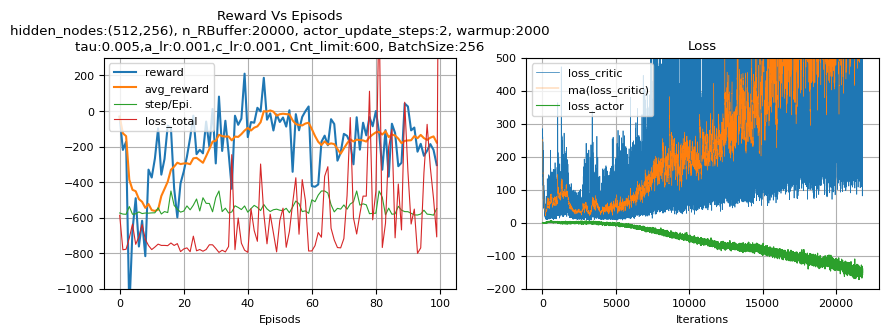

In [17]:
conditions = f'hidden_nodes:(512,256), n_RBuffer:{n_RBuffer}, \
actor_update_steps:{agent.actor_update_steps}, warmup:{agent.warmup}\n\
tau:{agent.tau},a_lr:{agent.a_lr},c_lr:{agent.c_lr}, \
Cnt_limit:{step_limit:02d}, BatchSize:{agent.batch_size}'

plt.figure(figsize=(10,3))
plt.subplot(121)
plt.title(f"Reward Vs Episods\n{conditions}")
plt.plot(ep_reward,label='reward')
plt.plot(total_avgr,label='avg_reward')
plt.plot(np.array(steps)/4-600,label='step/Epi.',linewidth=0.8)
plt.plot(loss_tot-800,label='loss_total',linewidth=0.8)
plt.xlabel("Episods")
plt.ylim(-1000,300)
plt.grid()
plt.legend()

plt.subplot(122)
plt.plot(losses[:,1],label='loss_critic',linewidth=0.5)
plt.plot(ma(losses[:,1]),label='ma(loss_critic)',linewidth=0.3)
plt.plot(losses[:,0],label='loss_actor',linewidth=0.8)
plt.title("Loss")
plt.xlabel("Iterations")
plt.ylim(-200,500)
plt.grid()
plt.legend()
plt.show()

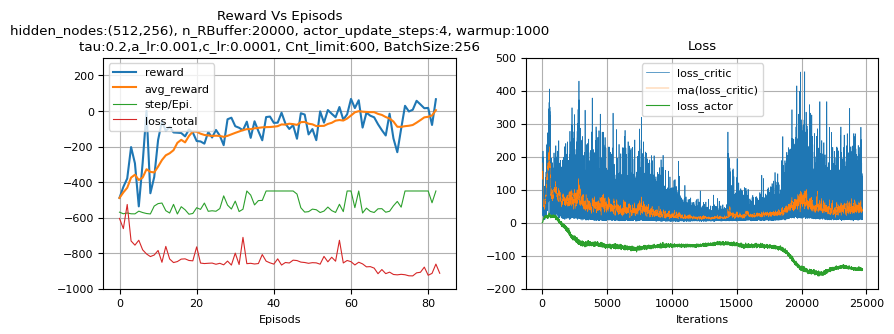

hidden_nodes:512, n_RBuffer:20000, actor_update_steps:4, warmup:1000
tau:0.01,a_lr:0.001,c_lr:0.001, Cnt_limit:600, BatchSize:256  
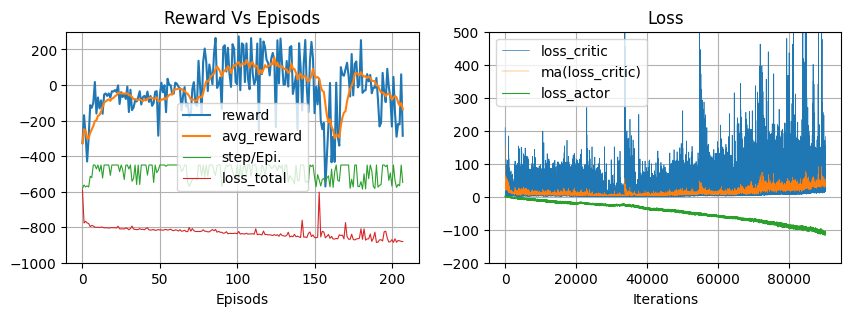

hidden_nodes:512, n_RBuffer:20000, actor_update_steps:4, warmup:1000
tau:0.01,a_lr:0.001,c_lr:0.001, Cnt_limit:600, BatchSize:256  
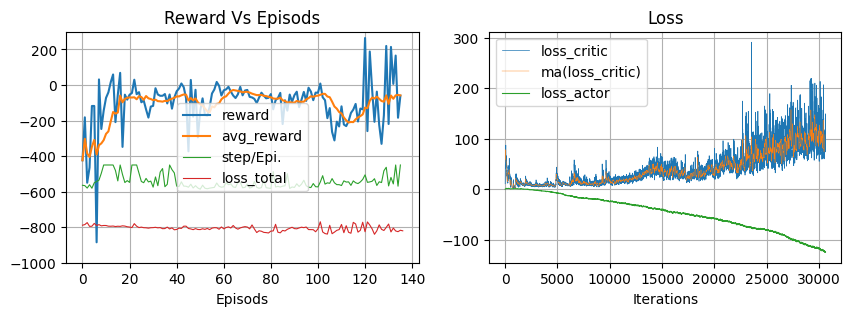

hidden_nodes:512, n_RBuffer:20000, actor_update_steps:4, warmup:1000
tau:0.05,a_lr:1e-05,c_lr:0.0001, Cnt_limit:600, BatchSize:256  
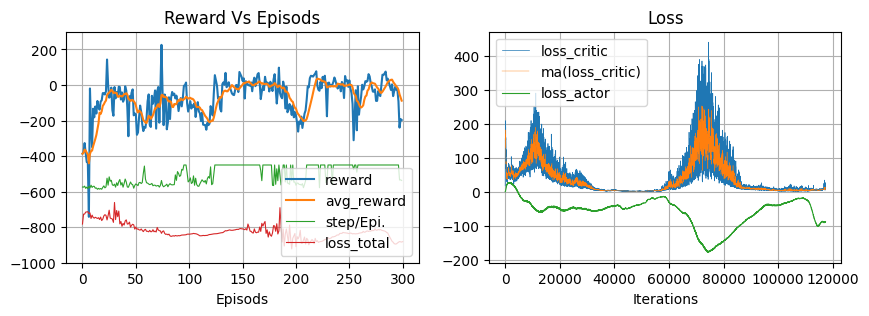

hidden_nodes:256, n_RBuffer:20000, actor_update_steps:2, warmup:1000
tau:0.05,a_lr:1e-05,c_lr:0.0001, Cnt_limit:600, BatchSize:256  
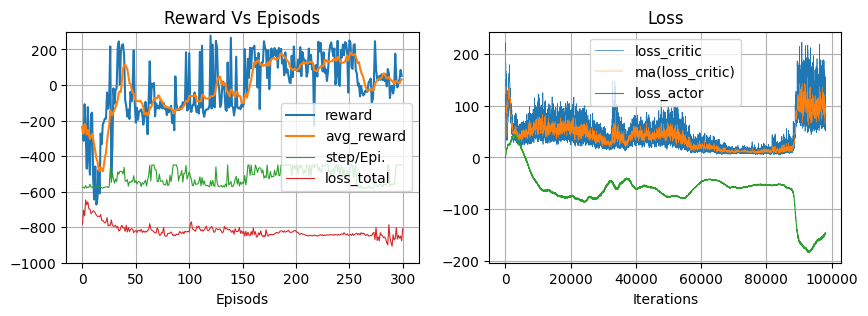

hidden_nodes:256, n_RBuffer:20000, actor_update_steps:2, warmup:1000
tau:0.05,a_lr:0.0001,c_lr:0.0001, Cnt_limit:600, BatchSize:256   
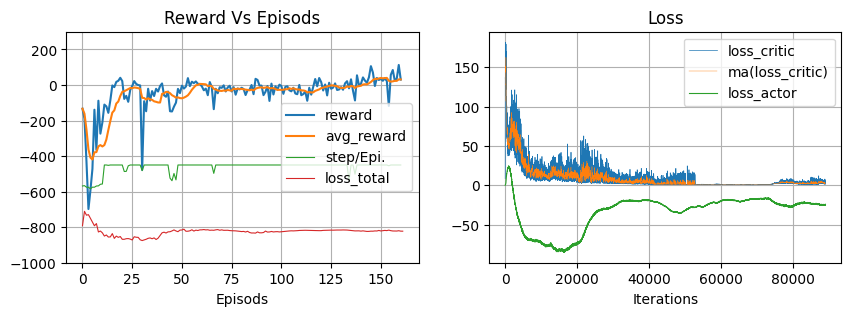

hidden_nodes:512, n_RBuffer:5000, actor_update_steps:2, warmup:200
tau:0.05,a_lr:0.0001,c_lr:0.0001, Cnt_limit:600, BatchSize:64  
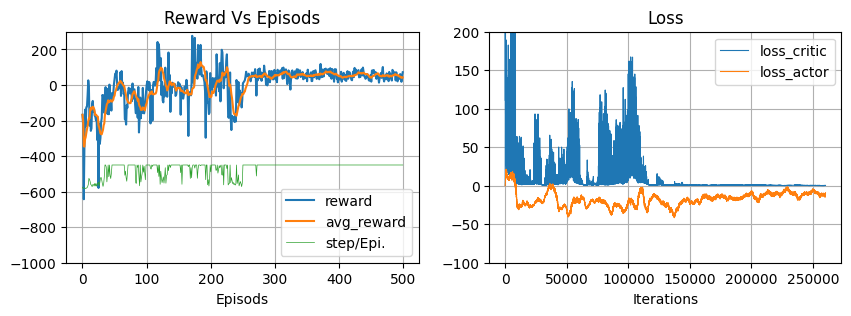